In [42]:
from src.fatemarkers import FateMarkers

import matplotlib
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import glob
import os

from nonlocal_correlations import *
from cell_graph_functions import *

In [43]:

annotation_names = {'LGR5': '0.C02.percentile99_class', 
                    'Chromogranin A': '0.C03.percentile99_class', 
                    'Cyclin D': '0.C04.percentile99_class', 
                    'Mucin 2': '1.C03.percentile99_class', 
                    'AldoB': '1.C04.percentile99_class', 
                    'Glucagon': '2.C02.percentile99_class', 
                    'Cyclin A': '2.C03.percentile99_class', 
                    'Agr2': '2.C04.percentile99_class', 
                    'Serotonin': '3.C02.percentile99_class', 
                    'Lysozyme': '3.C03.percentile99_class', 
                    }

def extract_markers(m, annotation_names):
    """
    Extract reference positional field and standardized marker fields.

    Parameters
    ----------
    m : object
        Object with attributes:
          - m.fields: ndarray of shape (N, num_fields)
          - m.field_names: list of field name strings, length = num_fields
    annotation_names : dict
        Mapping from human-readable marker name -> field_name in m.field_names

    Returns
    -------
    ref_field : (N,) ndarray
        Reference positional field (from "4.label").
    markers_array : (N, M) ndarray
        Array of marker intensities in standardized order.
    marker_names : list of str
        Human-readable marker names in the same order as markers_array.
    """

    field_names = list(m.field_names)

    # --- 1. Extract reference positional field (4.label) ---
    if "4.label" not in field_names:
        raise ValueError("Reference field '4.label' not found in m.field_names")
    ref_idx = field_names.index("4.label")
    ref_field = m.fields[:, ref_idx]

    # --- 2. Extract markers in standardized order ---
    markers_list = []
    marker_names = []

    for name, fname in annotation_names.items():
        if fname not in field_names:
            raise ValueError(f"Marker field '{fname}' for '{name}' not found in m.field_names")
        idx = field_names.index(fname)
        markers_list.append(m.fields[:, idx])
        marker_names.append(name)

    markers_array = np.column_stack(markers_list)  # shape (N, M)

    return ref_field, markers_array, marker_names


In [44]:
data_dir = '../NicoleData/20250929/fractal_output'

# choose one timepoint/well/round
timepoint = "day4p5-more" #"day4p5"
zarr_name = "r0.zarr"
well = "C01" #"A06"
round_name = "0_fused_zillum_registered"

# directory containing the organoid meshes
mesh_dir = f"{data_dir}/{timepoint}/{zarr_name}/{well[0]}/{well[1:]}/{round_name}/meshes/nnorg_linked_multi_annotated_class"

# collect all VTP files
organoid_paths = sorted(glob.glob(os.path.join(mesh_dir, "*.vtp")))

print(f"Found {len(organoid_paths)} organoids:")
for p in organoid_paths:
    print(" ", os.path.basename(p))

Found 114 organoids:
  1.vtp
  10.vtp
  100.vtp
  101.vtp
  102.vtp
  103.vtp
  107.vtp
  109.vtp
  11.vtp
  110.vtp
  111.vtp
  113.vtp
  114.vtp
  115.vtp
  118.vtp
  119.vtp
  12.vtp
  120.vtp
  121.vtp
  122.vtp
  123.vtp
  124.vtp
  127.vtp
  129.vtp
  13.vtp
  130.vtp
  131.vtp
  134.vtp
  137.vtp
  138.vtp
  139.vtp
  14.vtp
  15.vtp
  16.vtp
  17.vtp
  18.vtp
  19.vtp
  2.vtp
  20.vtp
  21.vtp
  22.vtp
  23.vtp
  24.vtp
  26.vtp
  27.vtp
  28.vtp
  29.vtp
  3.vtp
  30.vtp
  31.vtp
  32.vtp
  33.vtp
  34.vtp
  35.vtp
  36.vtp
  37.vtp
  38.vtp
  4.vtp
  40.vtp
  41.vtp
  42.vtp
  43.vtp
  44.vtp
  46.vtp
  47.vtp
  48.vtp
  5.vtp
  50.vtp
  51.vtp
  52.vtp
  53.vtp
  54.vtp
  55.vtp
  56.vtp
  57.vtp
  58.vtp
  59.vtp
  6.vtp
  60.vtp
  61.vtp
  62.vtp
  63.vtp
  64.vtp
  65.vtp
  66.vtp
  67.vtp
  68.vtp
  69.vtp
  7.vtp
  71.vtp
  72.vtp
  74.vtp
  75.vtp
  76.vtp
  77.vtp
  78.vtp
  79.vtp
  8.vtp
  81.vtp
  82.vtp
  83.vtp
  84.vtp
  85.vtp
  87.vtp
  88.vtp
  89.vtp
  9.vtp

In [45]:
# ---------- Parameters ----------
k_values = [1, 2, 3, 4, 5]
n_perms = 999

# ---------- Initialize storage ----------
kNN_ensemble = {k: [] for k in k_values}  # list of arrays per organoid

global_I_ensemble = {k: [] for k in k_values}
global_perm_ensemble = {k: [] for k in k_values}

# ---------- Process each organoid ----------
for path in organoid_paths:
    print(f"Processing {path}")
    
    # Load mesh and get cell graph
    m = FateMarkers()
    m.load_mesh_from_file(path)

    try:
        ref_field, markers_array, marker_names = extract_markers(m, annotation_names)
    except Exception as e:
        continue
    
    n_markers = len(marker_names)
    _, patch_centers = get_patch_centers(m.v, ref_field)
    cell_graph = build_cell_graph(m.f, ref_field)
    
    # Extract markers at cell centers
    cell_markers = markers_array[patch_centers, :]
    positive_indices, positive_labels = positive_indices_and_labels(cell_markers)
    
    for k in k_values:
        # --- kNN composition for all focal markers ---
        comp_per_marker = []
        for focal_idx in range(n_markers):
            try:
                _, _, _, comp_accum = kNN_marker_composition(
                    cell_graph, positive_labels, focal_marker_idx=focal_idx, k=k
                )
                comp_per_marker.append(comp_accum)  # shape (N_focal_cells, n_markers)

            except ValueError:
                # print(f"Error! Skipping {marker_names[focal_idx]} in {path} (no positives).")
                comp_per_marker.append(None)  # no focal cells → None

        # store as an object array of length n_markers
        comp_per_marker = np.array(comp_per_marker, dtype=object)  
        # Each entry: (N_focal_cells, n_markers) or None
        kNN_ensemble[k].append(comp_per_marker)


        # --- Moran's I ---
        W, nodes = build_weight_matrix_kNN(cell_graph, k=k, row_standardize=False)
        global_I_obs, local_I_obs, global_I_perm, p_values = permutation_test_cross_morans_I(
            positive_labels, positive_labels, W, n_perms=n_perms
        )
        global_I_ensemble[k].append(global_I_obs)
        global_perm_ensemble[k].append(global_I_perm)

Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/1.vtp


/home/fmoller/Projects/LearningOrganoids/SphericalHarmonics/cell_graph_functions.py:437: RuntimeWarning: invalid value encountered in divide
  global_I = (N / S0) * (num / np.sum(Z_X**2, axis=0)[:, None])
/home/fmoller/Projects/LearningOrganoids/SphericalHarmonics/cell_graph_functions.py:443: RuntimeWarning: invalid value encountered in divide
  local_I = (Z_X[:, :, None] / m2_X[None, :, None]) * WZ_Y[:, None, :]


Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/10.vtp
Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/100.vtp
Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/101.vtp
Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/102.vtp
Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/103.vtp
Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/107.vtp
Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/m

/home/fmoller/Projects/LearningOrganoids/SphericalHarmonics/cell_graph_functions.py:437: RuntimeWarning: divide by zero encountered in scalar divide
  global_I = (N / S0) * (num / np.sum(Z_X**2, axis=0)[:, None])


Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/69.vtp
Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/7.vtp
Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/71.vtp
Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/72.vtp
Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/74.vtp
Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated_class/75.vtp
Processing ../NicoleData/20250929/fractal_output/day4p5-more/r0.zarr/C/01/0_fused_zillum_registered/meshes/

In [46]:
kNN_mean = {k: [] for k in k_values}   # (n_markers, n_markers)
kNN_std  = {k: [] for k in k_values}
kNN_sem  = {k: [] for k in k_values}

for k in k_values:
    print(f"\nAggregating k={k} ...")
    # Each entry: object array of shape (n_markers,)
    # comp_per_marker[focal_idx] = (N_focal_cells, n_markers) or None
    all_results = [[] for _ in range(n_markers)]  

    # --- collect results across organoids ---
    for comp_per_organoid in kNN_ensemble[k]:
        for focal_idx in range(n_markers):
            arr = comp_per_organoid[focal_idx]
            if arr is not None:
                all_results[focal_idx].append(arr)

    # --- concatenate across organoids ---
    mean_list, std_list, sem_list = [], [], []
    for focal_idx in range(n_markers):
        if len(all_results[focal_idx]) == 0:
            mean_list.append(np.full((n_markers,), np.nan))
            std_list.append(np.full((n_markers,), np.nan))
            sem_list.append(np.full((n_markers,), np.nan))
        else:
            pooled = np.concatenate(all_results[focal_idx], axis=0)  # (total_cells, n_markers)
            mean_list.append(pooled.mean(axis=0))
            std_list.append(pooled.std(axis=0))
            sem_list.append(pooled.std(axis=0) / np.sqrt(len(pooled)))

    # Store as arrays (n_markers, n_markers)
    kNN_mean[k] = np.vstack(mean_list)
    kNN_std[k]  = np.vstack(std_list)
    kNN_sem[k]  = np.vstack(sem_list)


Aggregating k=1 ...

Aggregating k=2 ...

Aggregating k=3 ...

Aggregating k=4 ...

Aggregating k=5 ...


In [47]:
# --- Aggregate global Moran's I across organoids ---
# Stack results per k (n_organoids, M, M)
for k in k_values:
    global_I_ensemble[k] = np.stack(global_I_ensemble[k], axis=0)        # (n_organoids, M, M)
    global_perm_ensemble[k] = np.stack(global_perm_ensemble[k], axis=0)  # (n_organoids, n_perms, M, M)

# --- Compute ensemble mean over organoids ---
ensemble_global_I_mean = {k: np.nanmean(global_I_ensemble[k], axis=0) for k in k_values}  # (M, M)

# --- Concatenate permutation samples across organoids ---
ensemble_global_perm = {}
ensemble_p_values = {}
for k in k_values:
    perm_all = np.concatenate(global_perm_ensemble[k], axis=0)  # (n_organoids*n_perms, M, M)
    ensemble_global_perm[k] = perm_all

    # Compute empirical two-sided p-values based on ensemble mean
    obs_mean = ensemble_global_I_mean[k]
    p_val = np.mean(np.abs(perm_all) >= np.abs(obs_mean[None, :, :]), axis=0)
    ensemble_p_values[k] = p_val

Text(0.5, 0.98, 'kNN Neighbor Compositions Across Organoids')

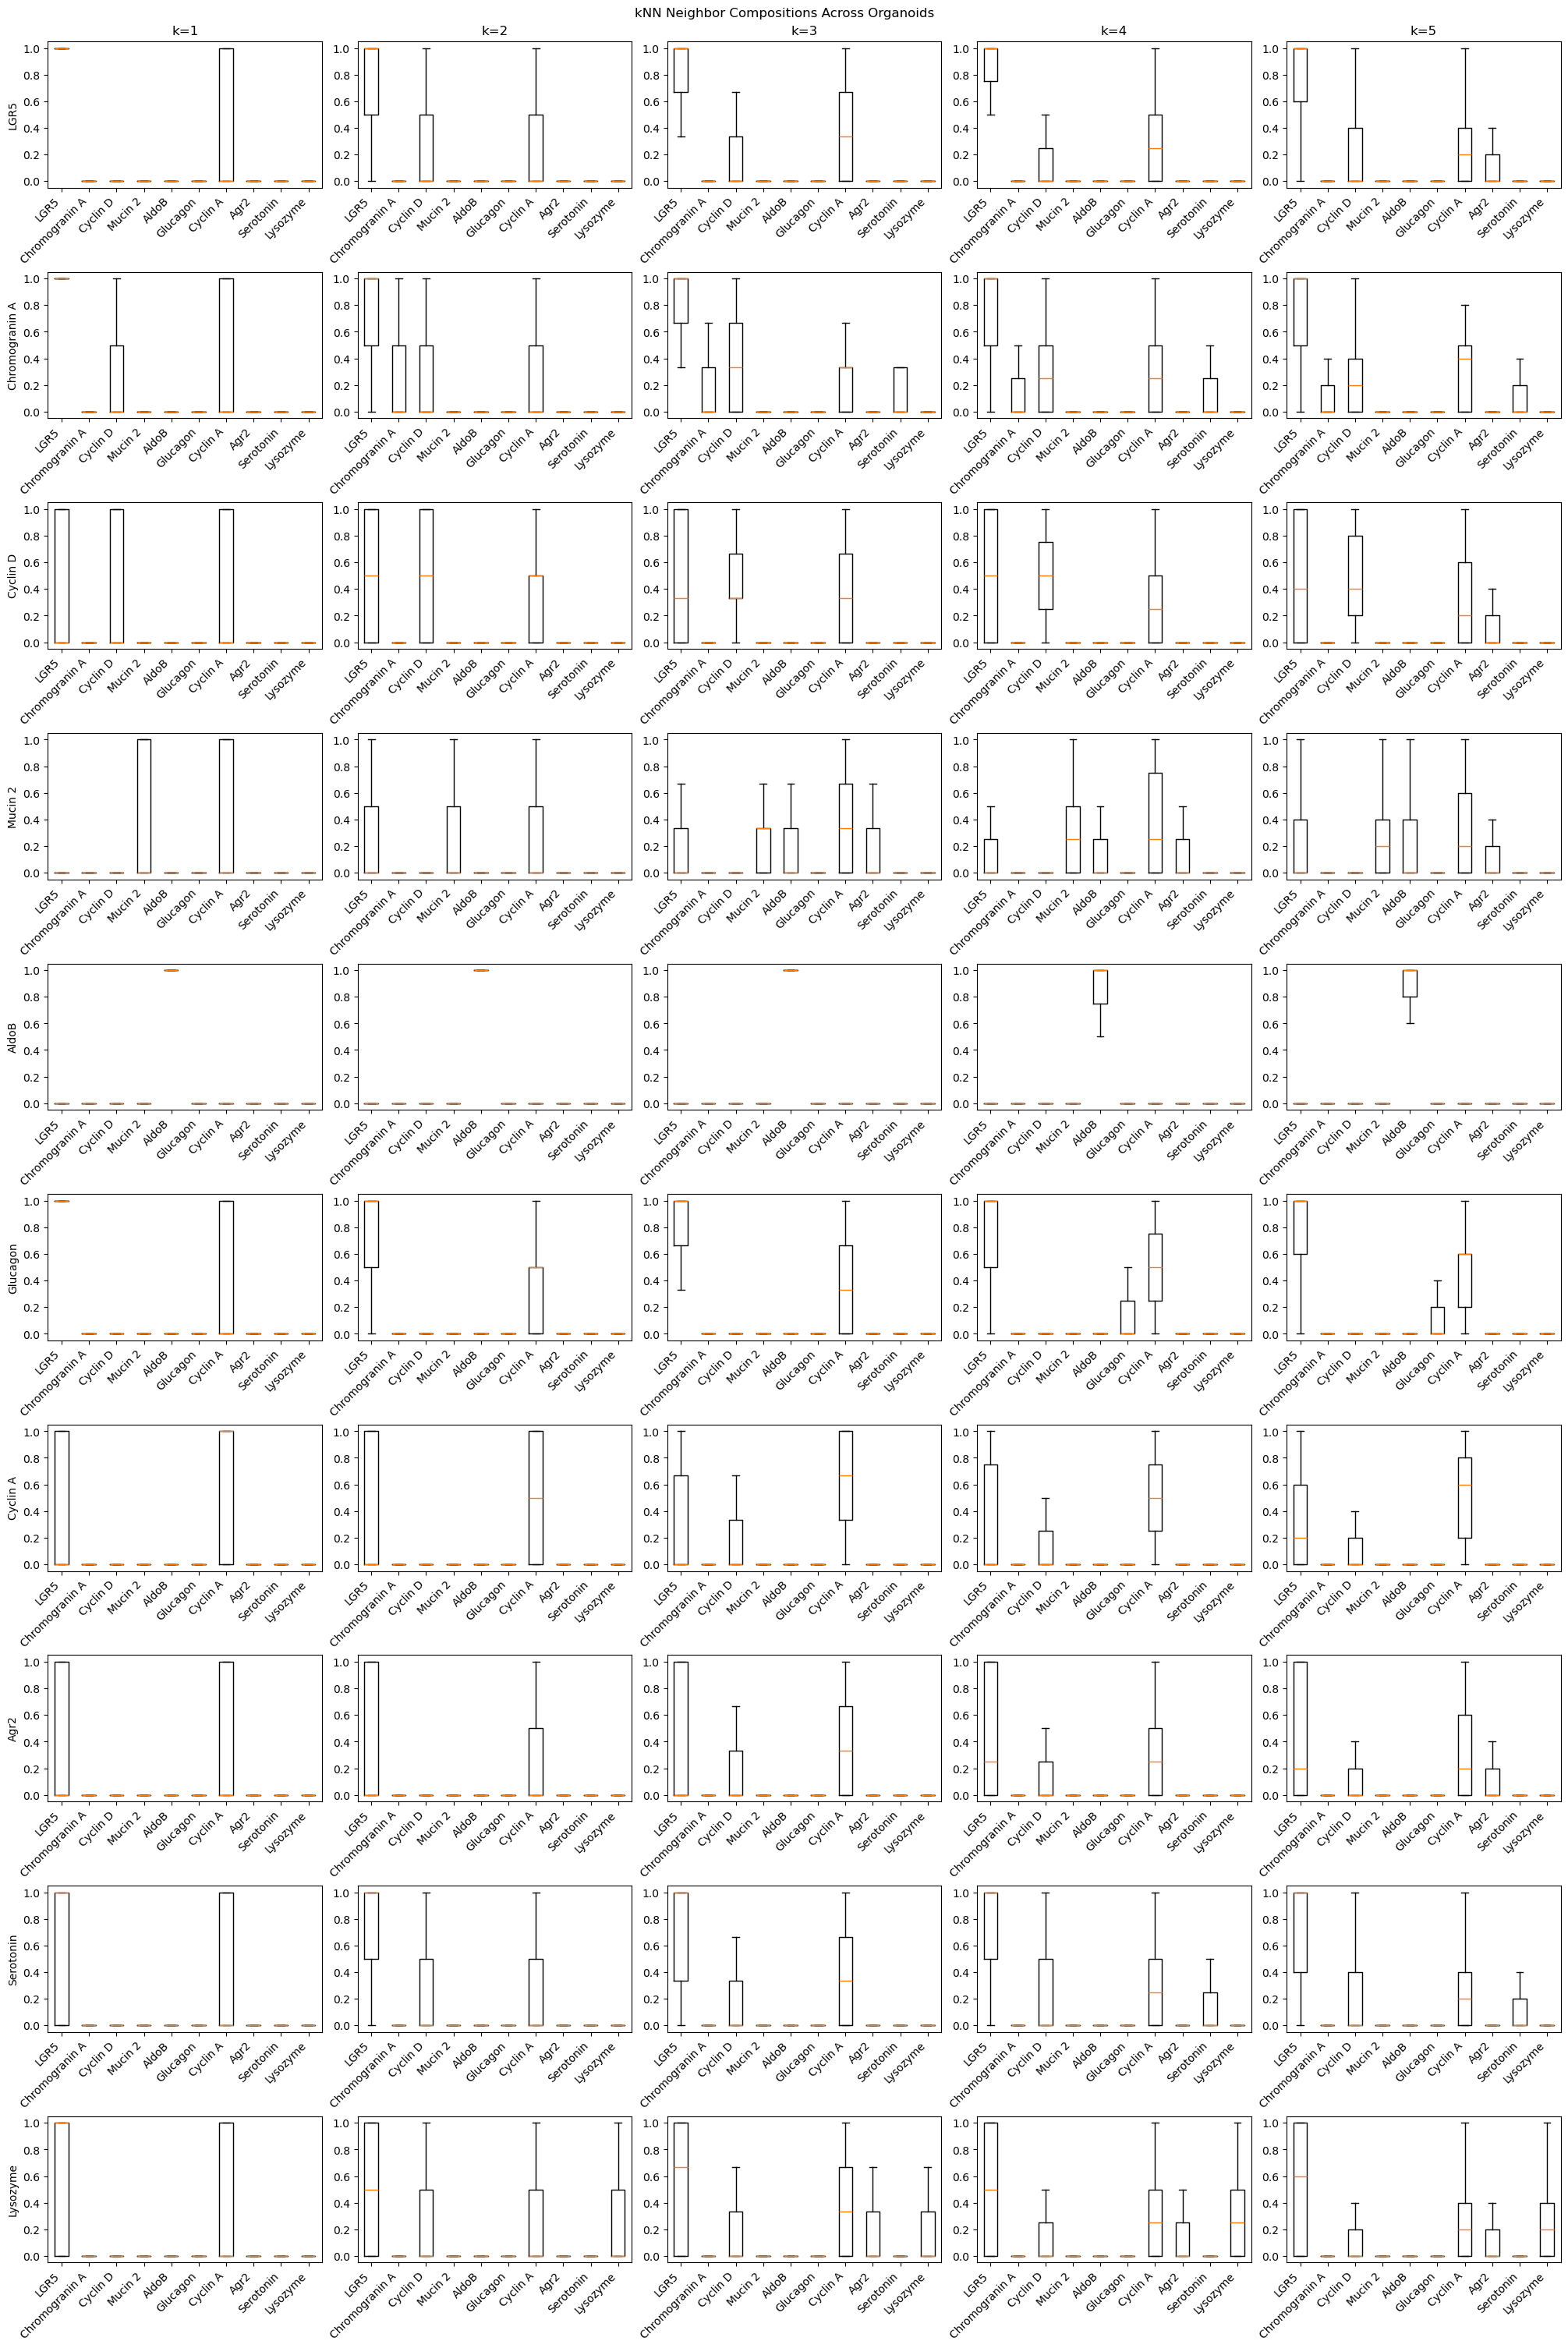

In [48]:
n_k = len(k_values)
fig, axes = plt.subplots(n_markers, n_k, figsize=(4*n_k, 3*n_markers), constrained_layout=True)

# Ensure axes is 2D array even if n_markers or n_k == 1
if n_markers == 1:
    axes = axes[None, :]
if n_k == 1:
    axes = axes[:, None]

for i, focal_idx in enumerate(range(n_markers)):
    for j, k in enumerate(k_values):
        # Gather pooled compositions across all organoids
        pooled = []
        for comp_per_organoid in kNN_ensemble[k]:
            arr = comp_per_organoid[focal_idx]
            if arr is not None:
                pooled.append(arr)
        if len(pooled) == 0:
            pooled_arr = np.full((1, n_markers), np.nan)
        else:
            pooled_arr = np.concatenate(pooled, axis=0)  # shape (total_cells, n_markers)

        # Create boxplot: one box per neighbor marker
        ax = axes[i, j]
        ax.boxplot(pooled_arr, showfliers=False)
        if i == 0:
            ax.set_title(f"k={k}")
        if j == 0:
            ax.set_ylabel(marker_names[focal_idx])
        
        ax.set_xticks(range(1, n_markers+1))
        ax.set_xticklabels(marker_names, rotation=45, ha='right')

plt.suptitle("kNN Neighbor Compositions Across Organoids")

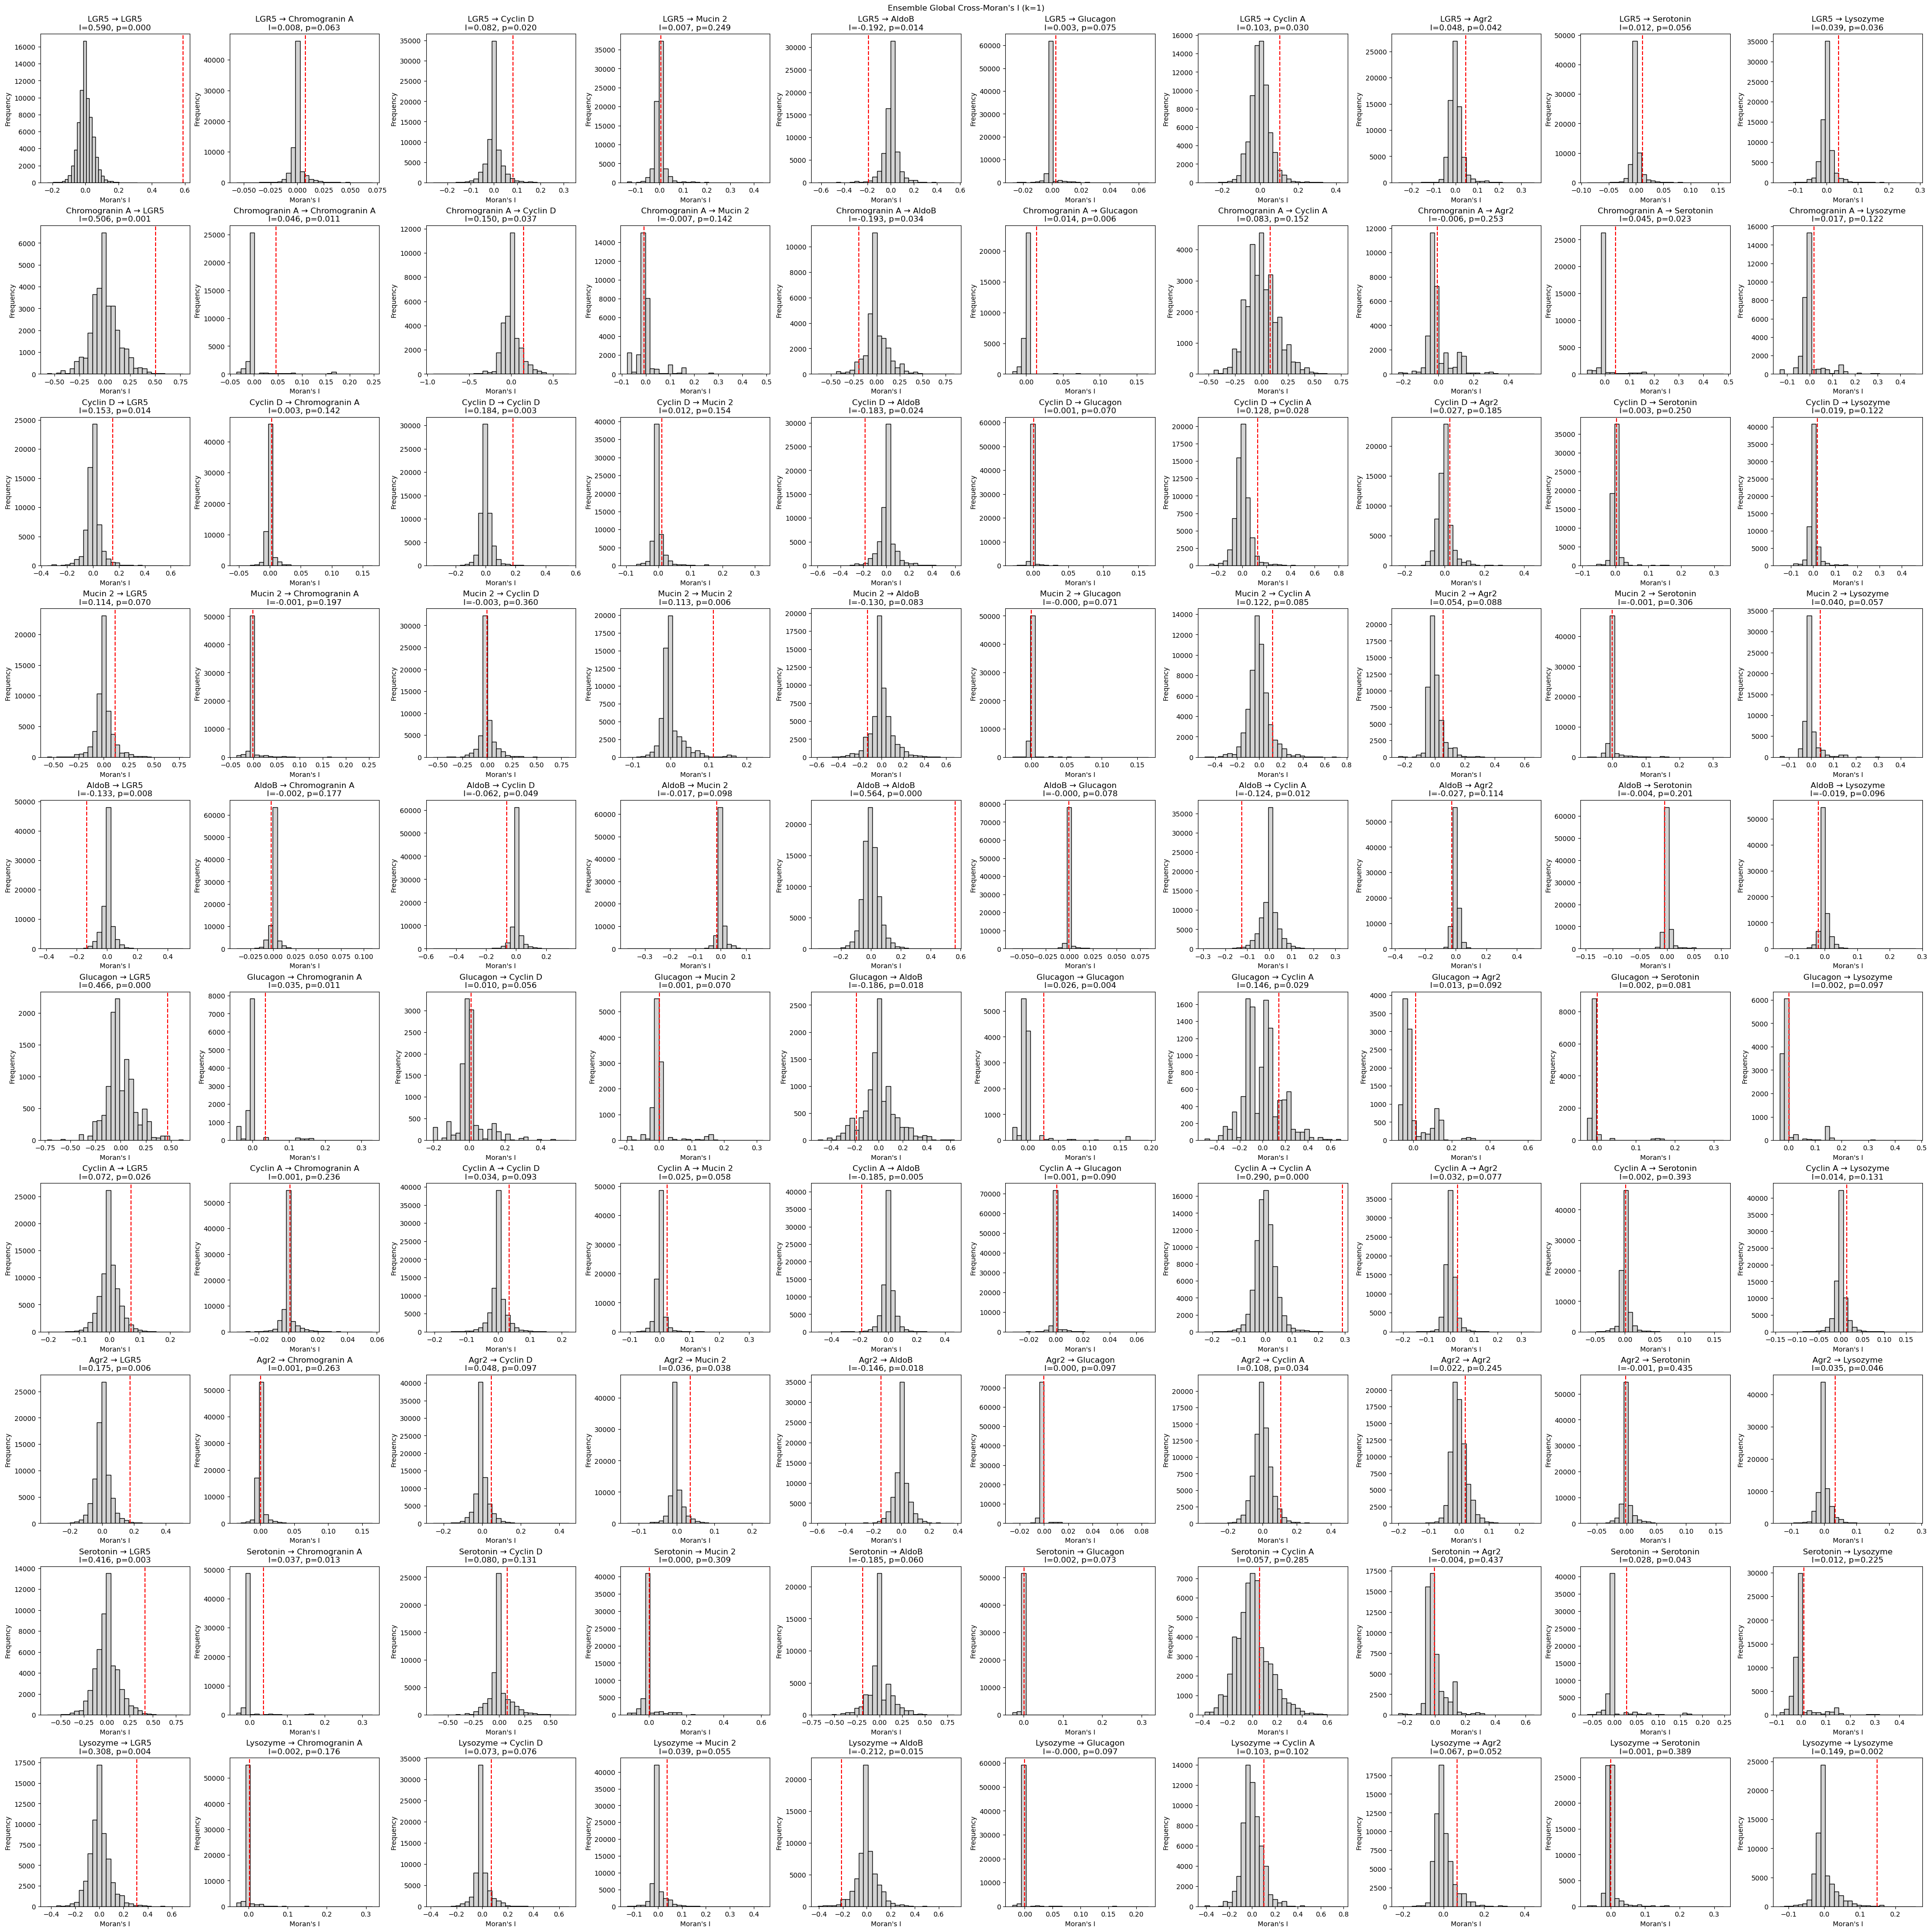

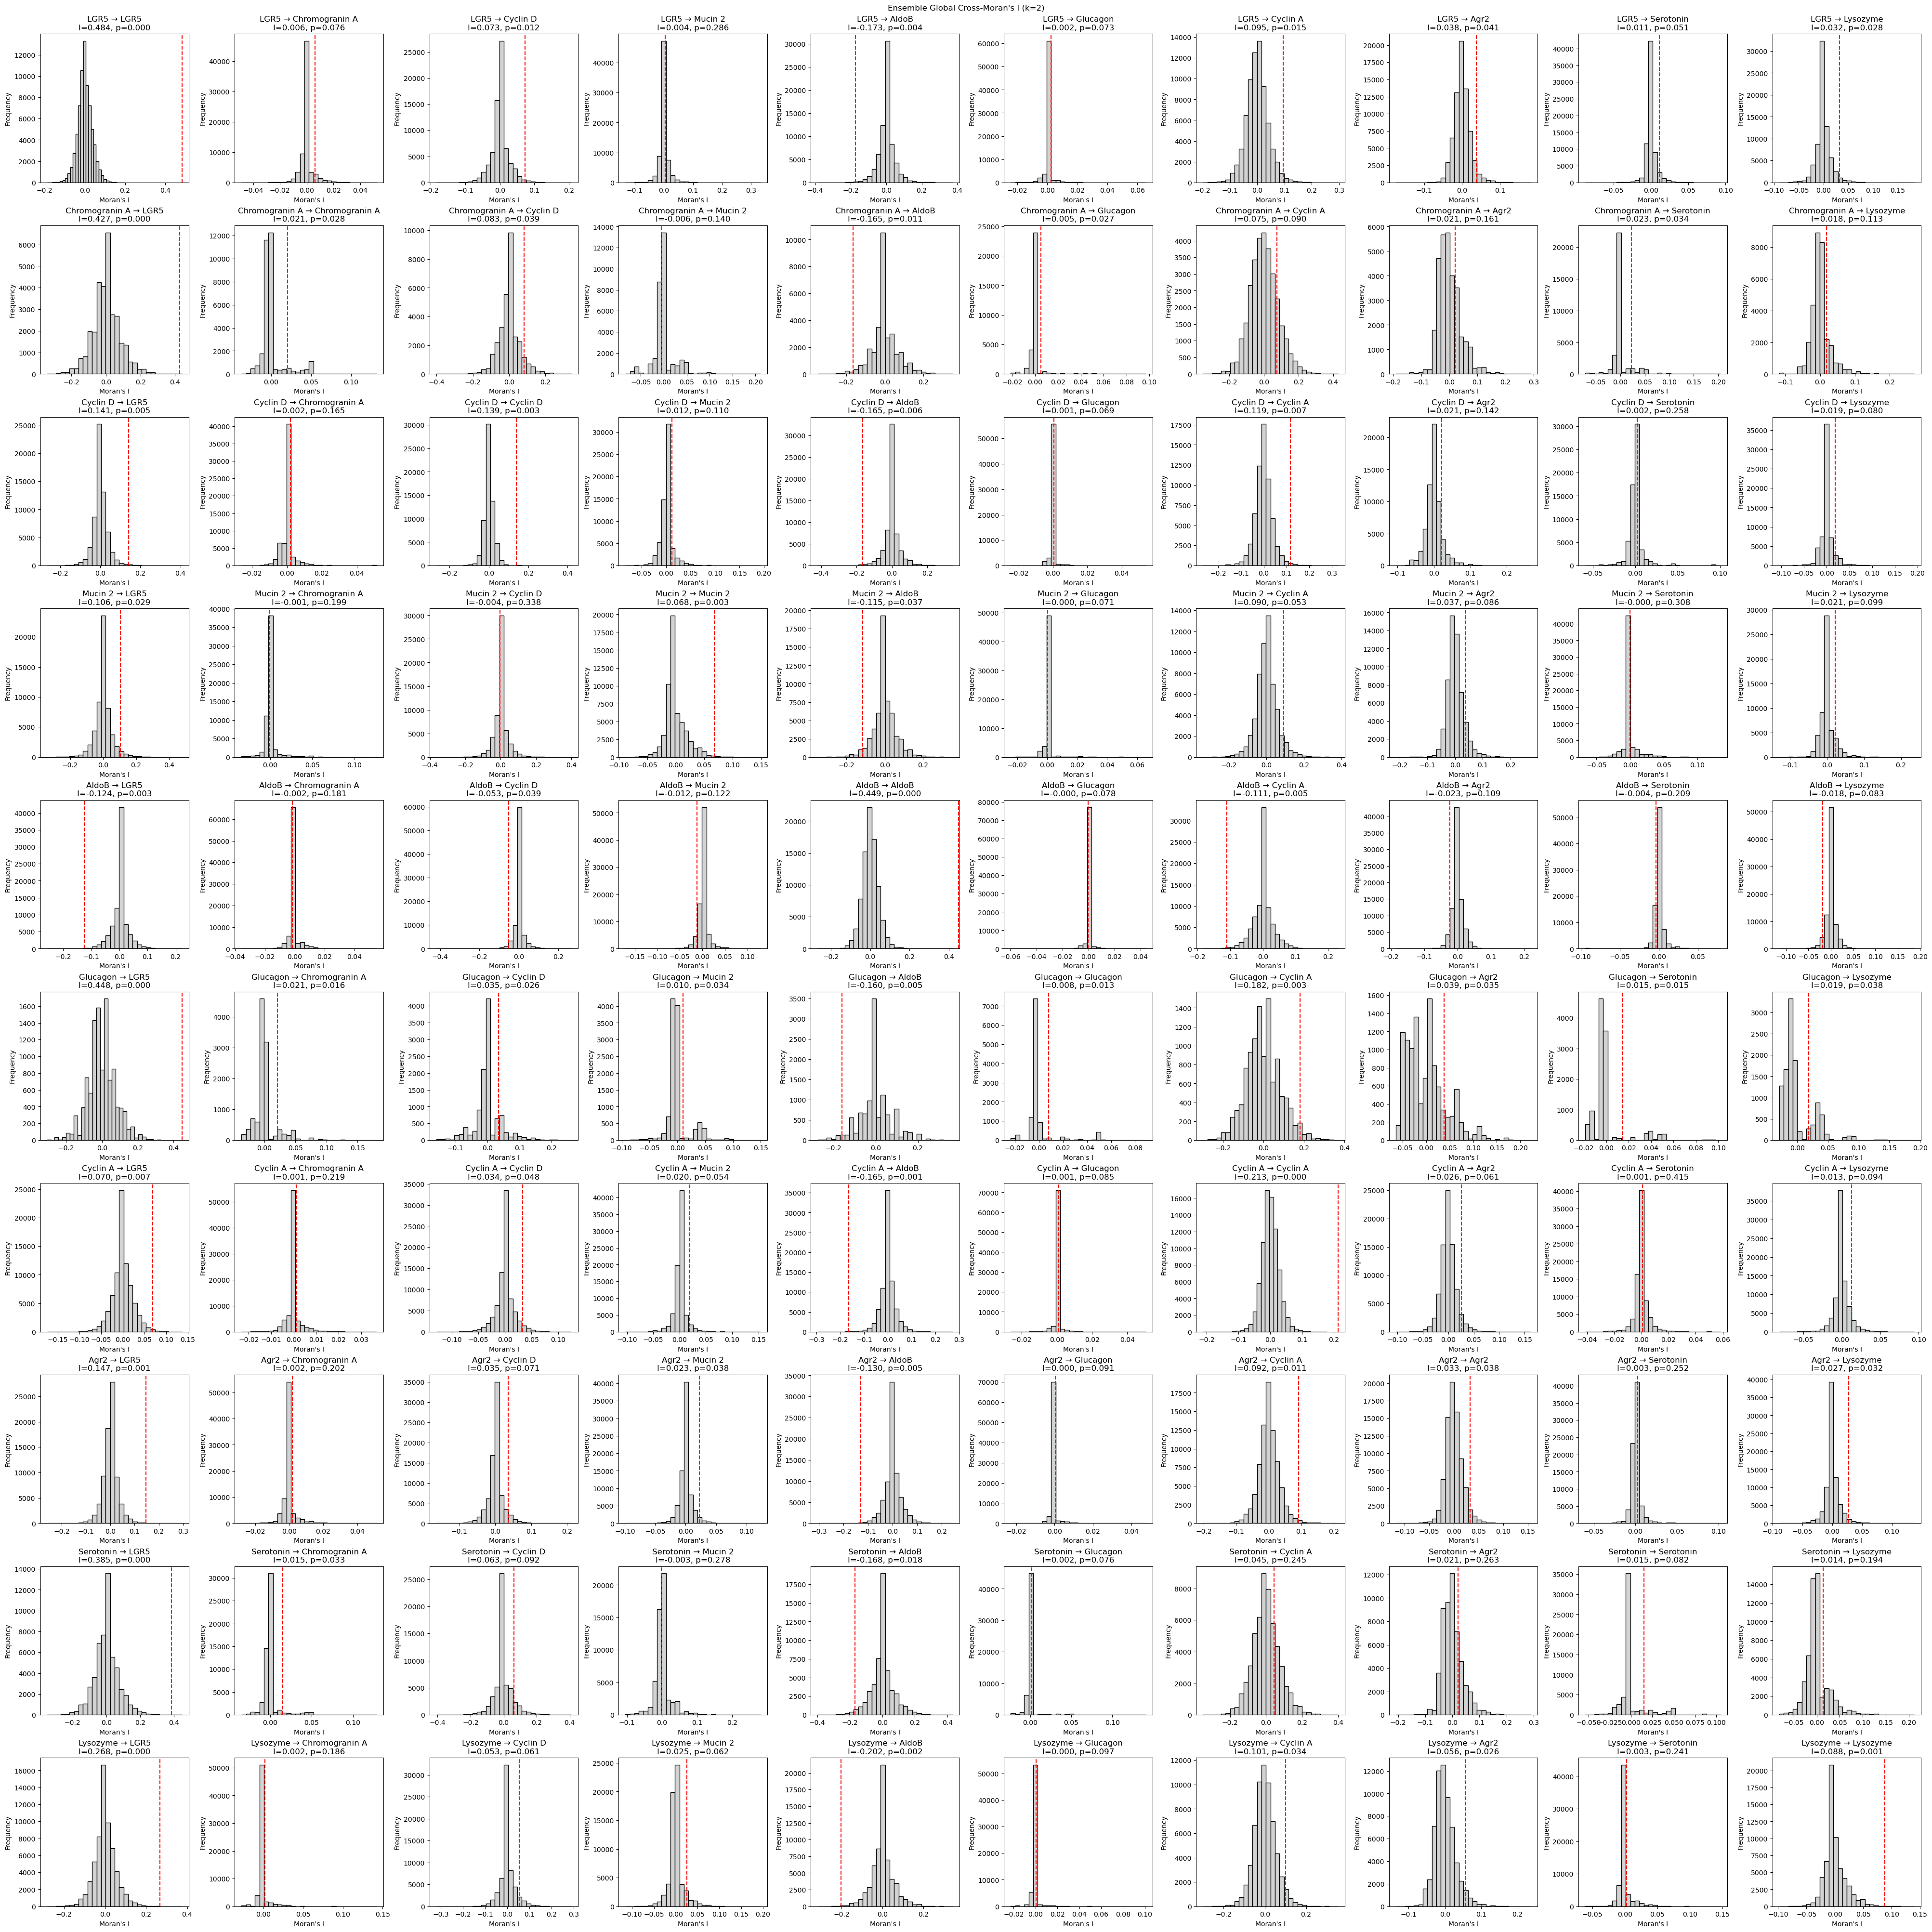

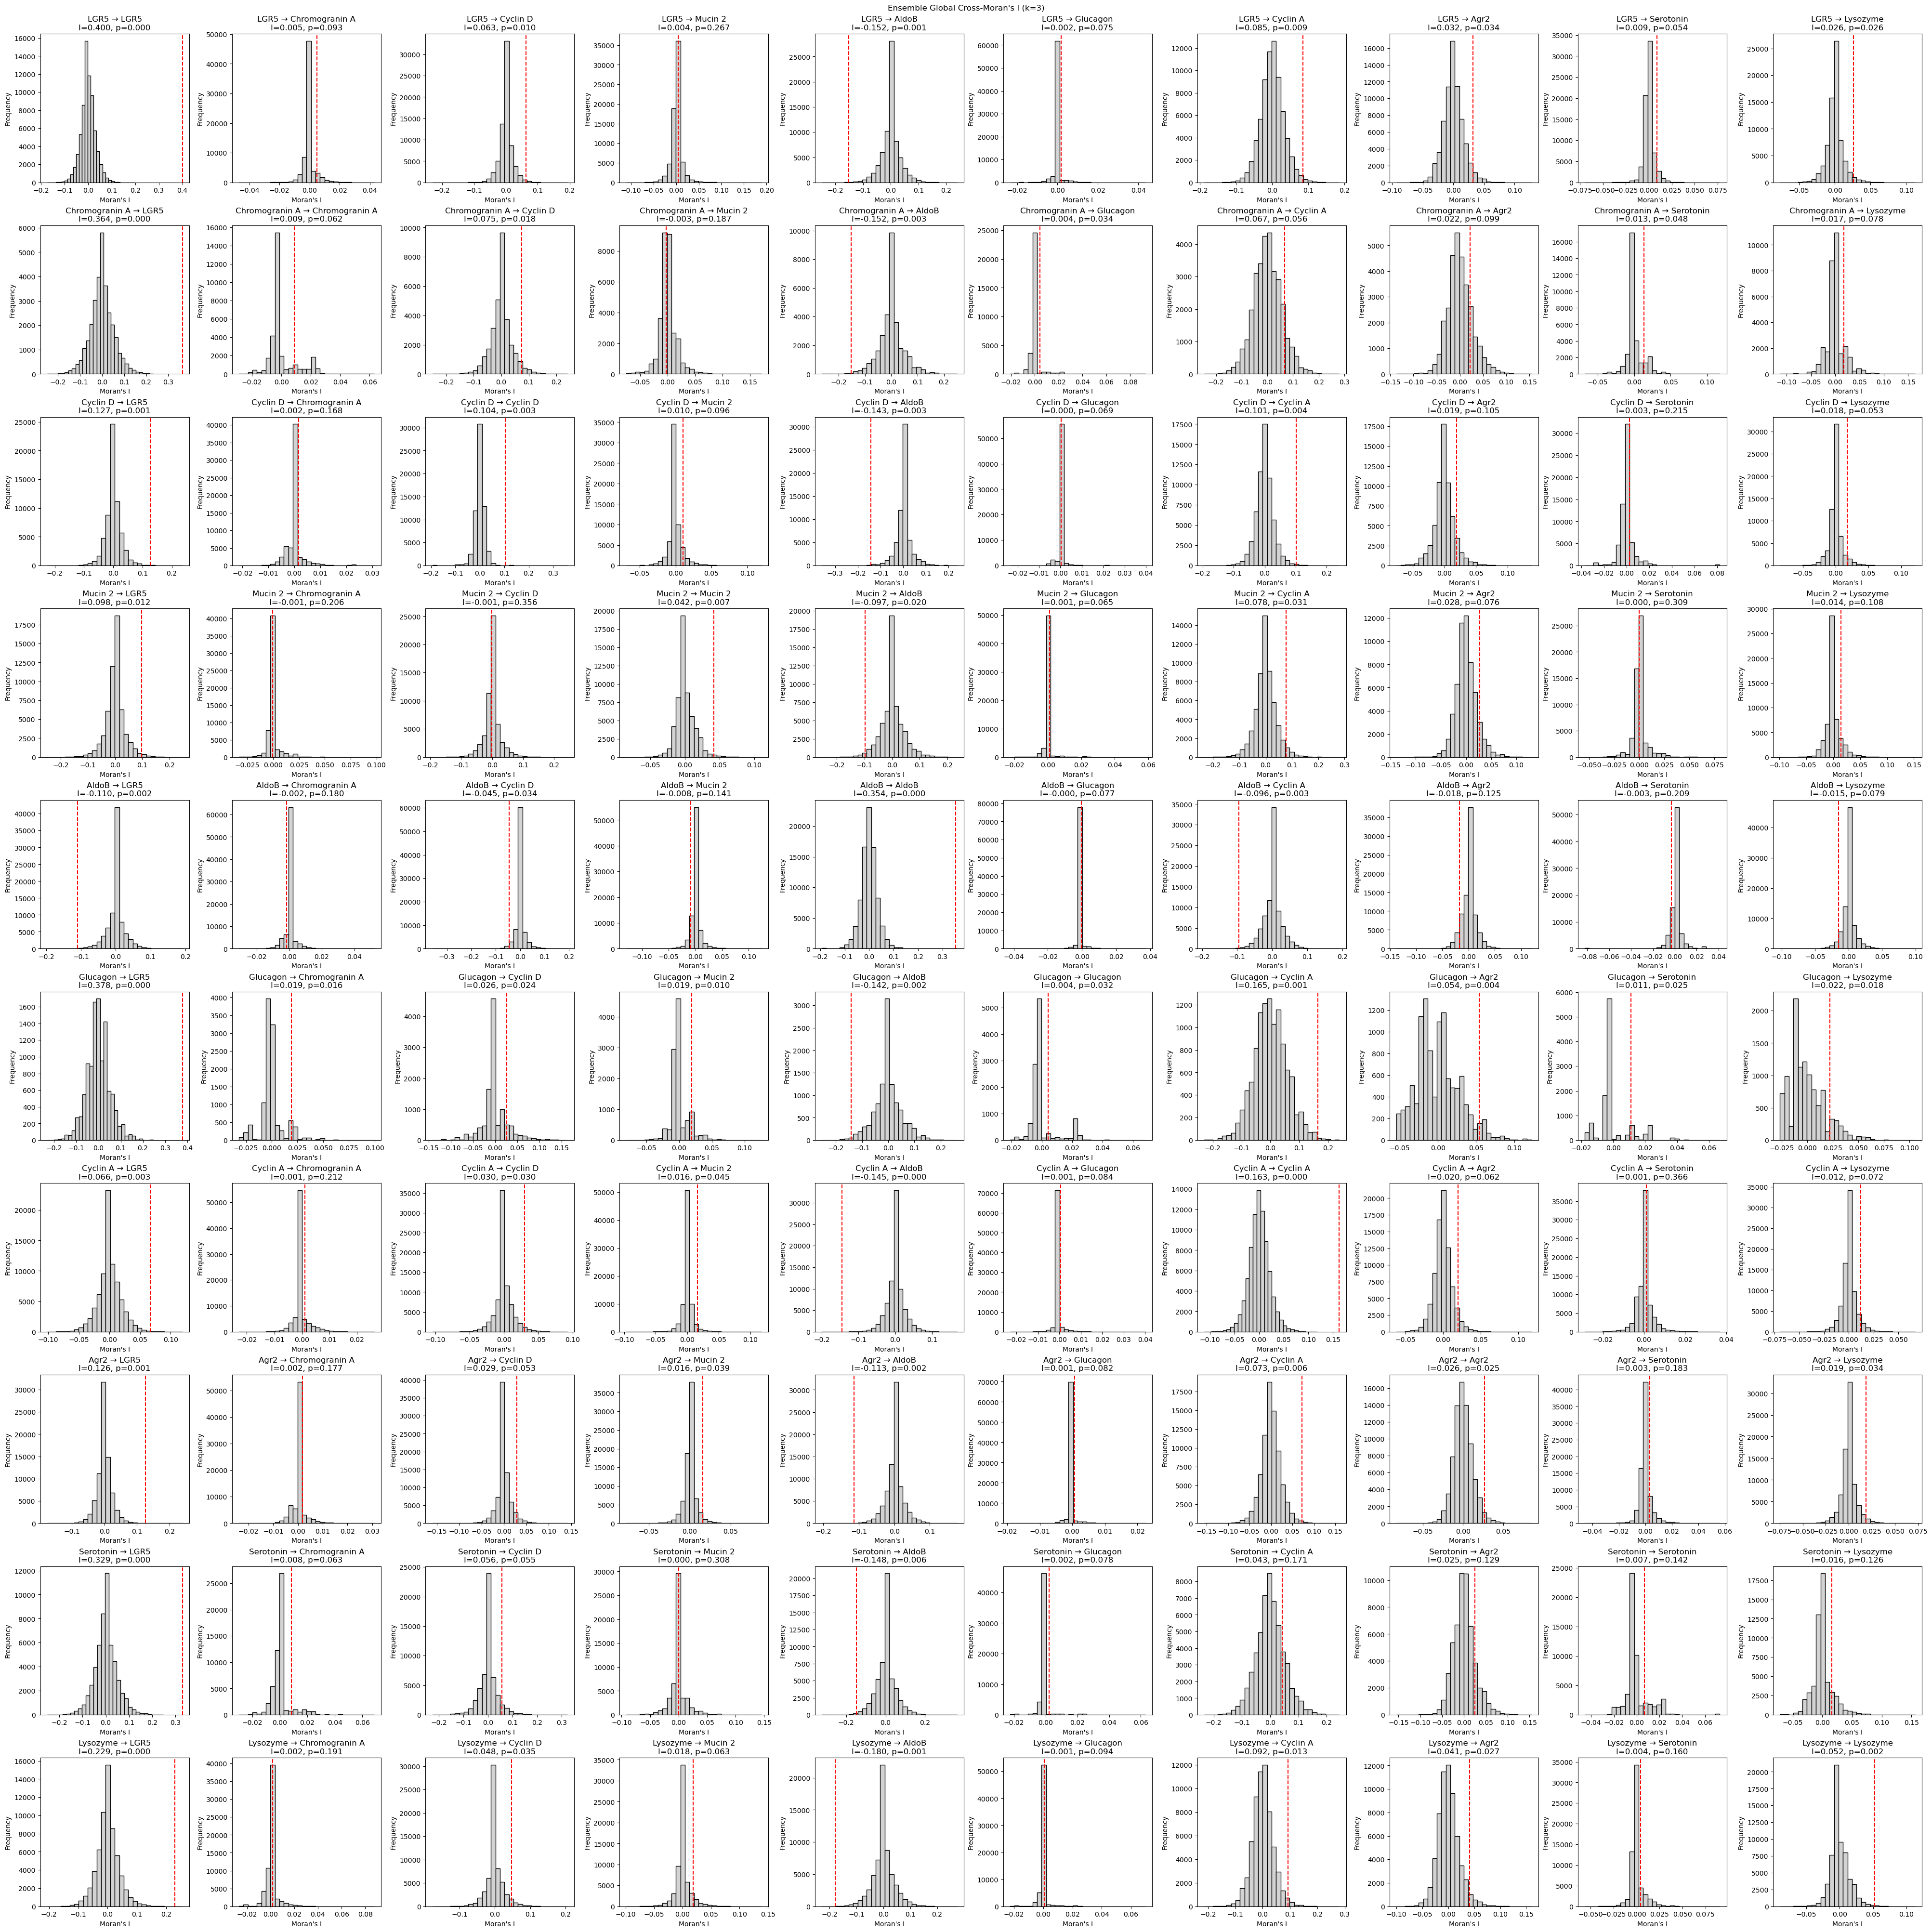

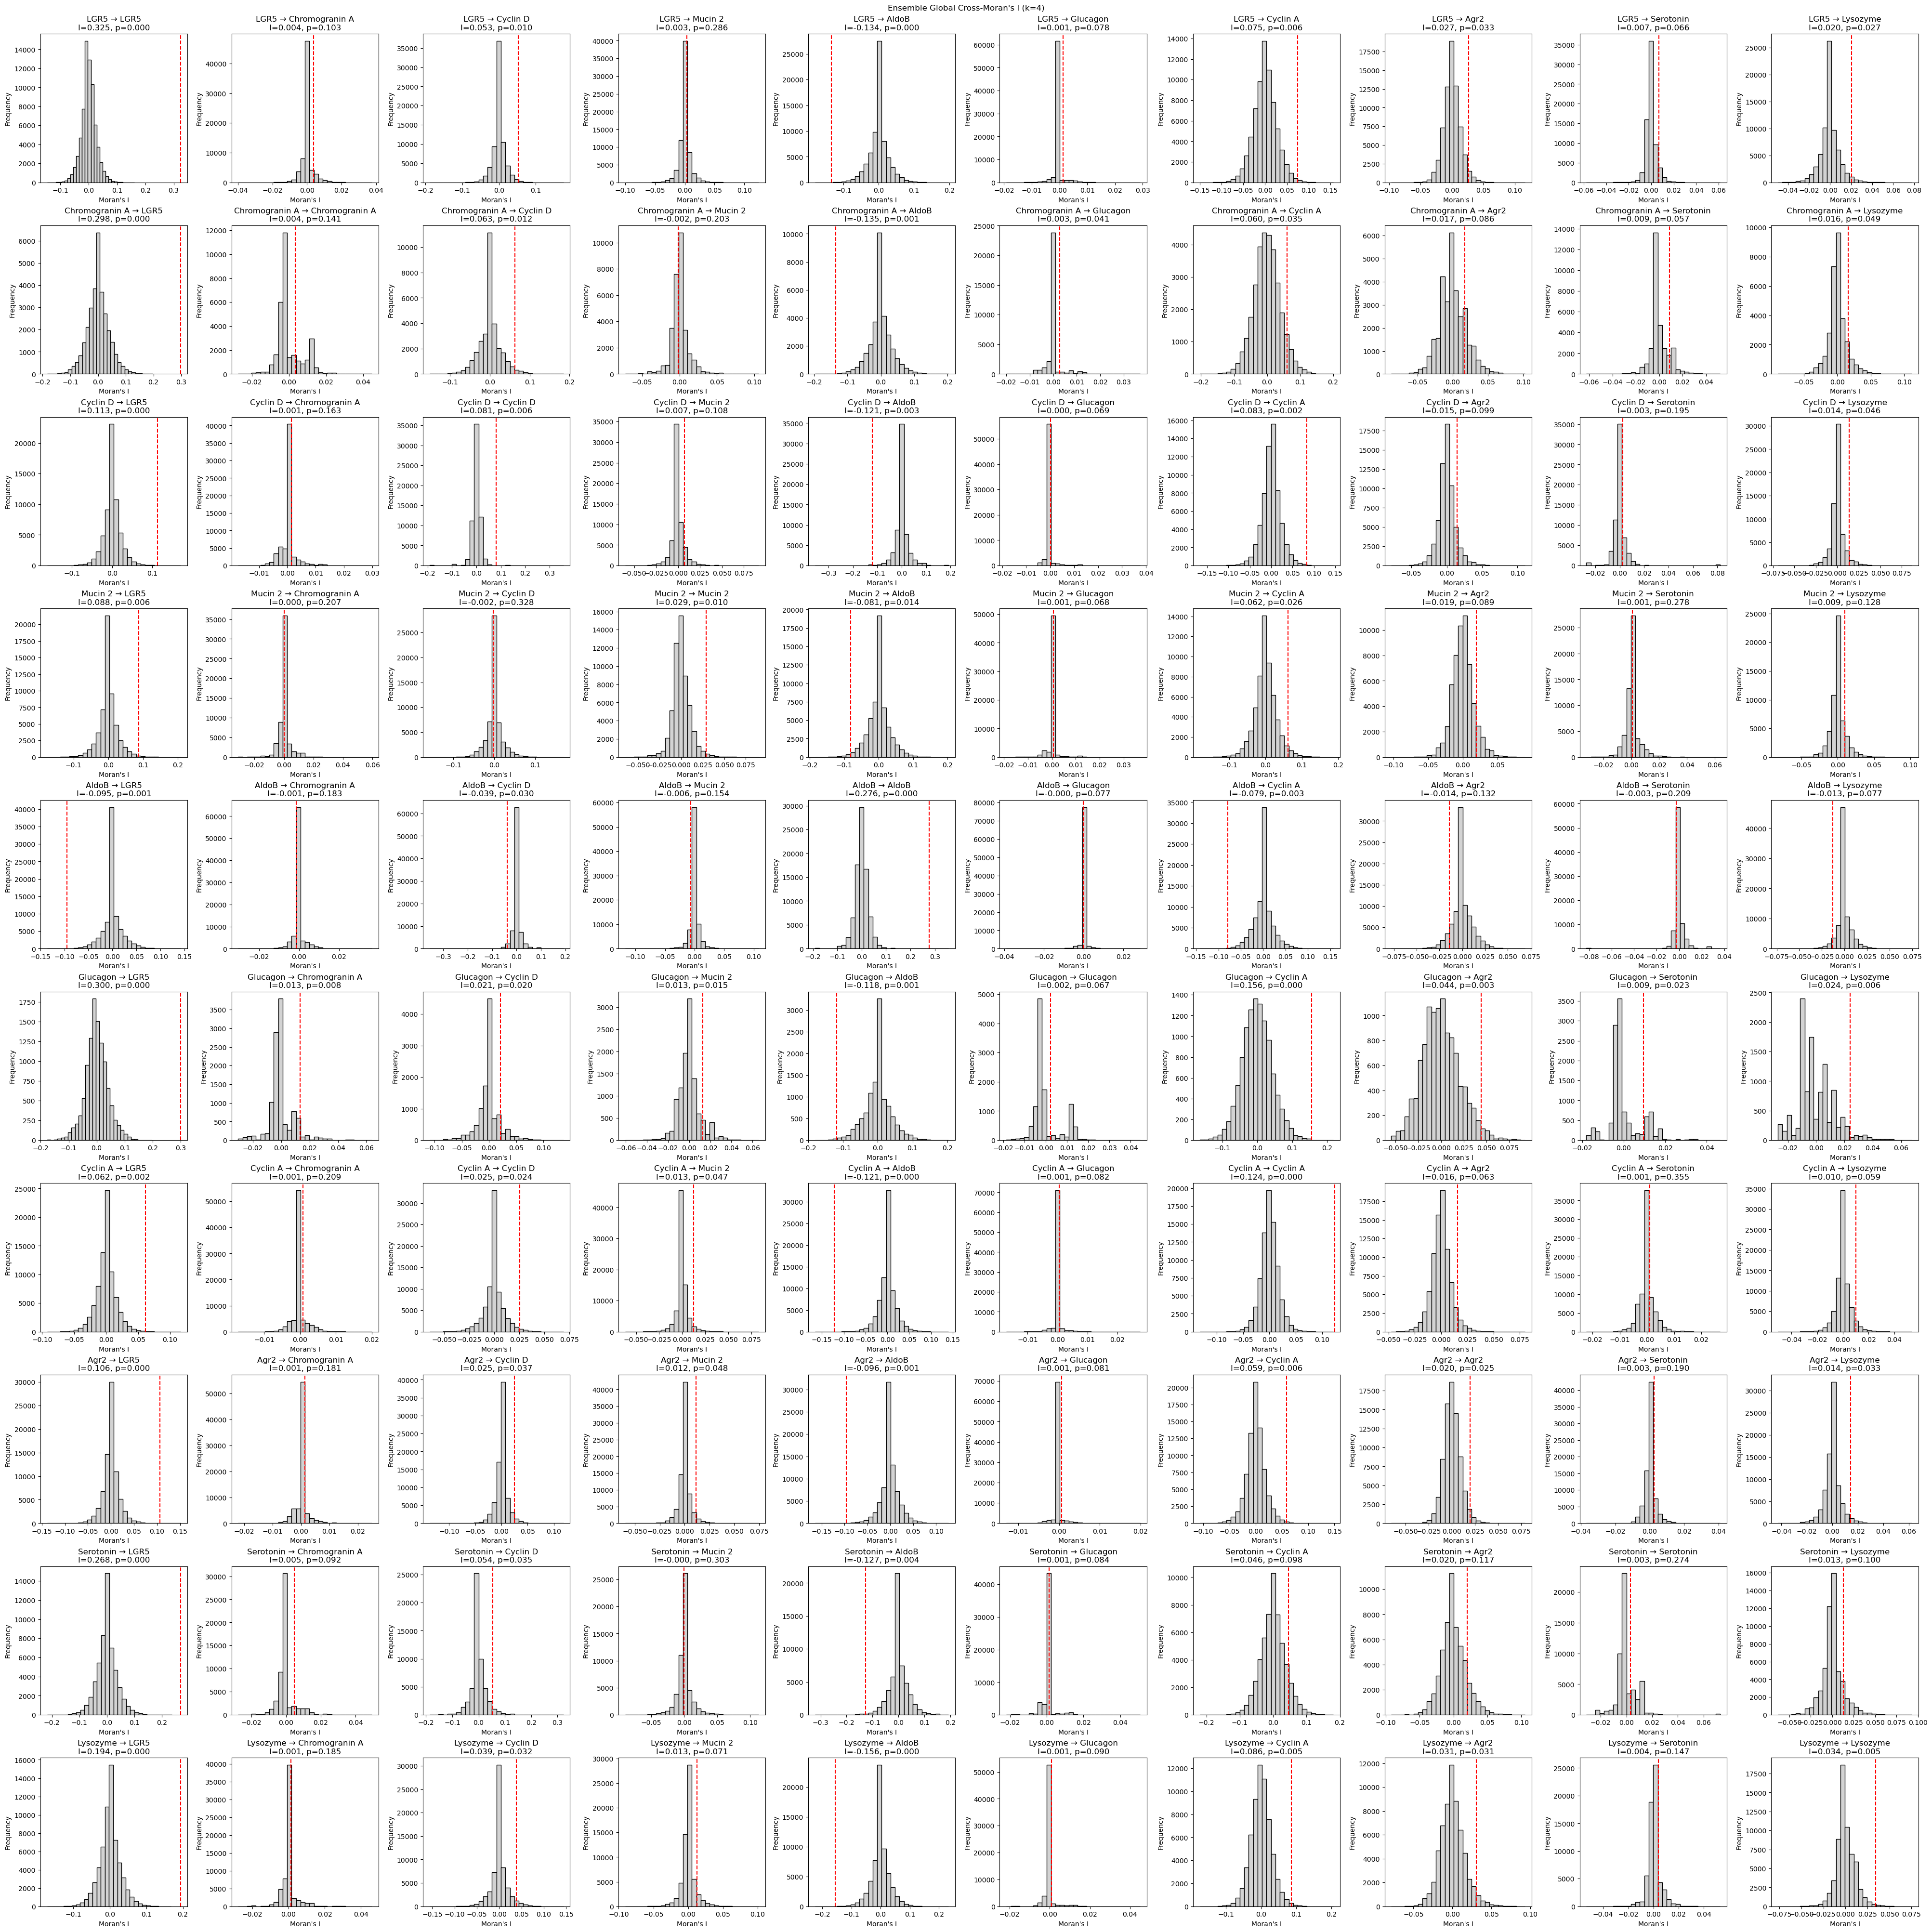

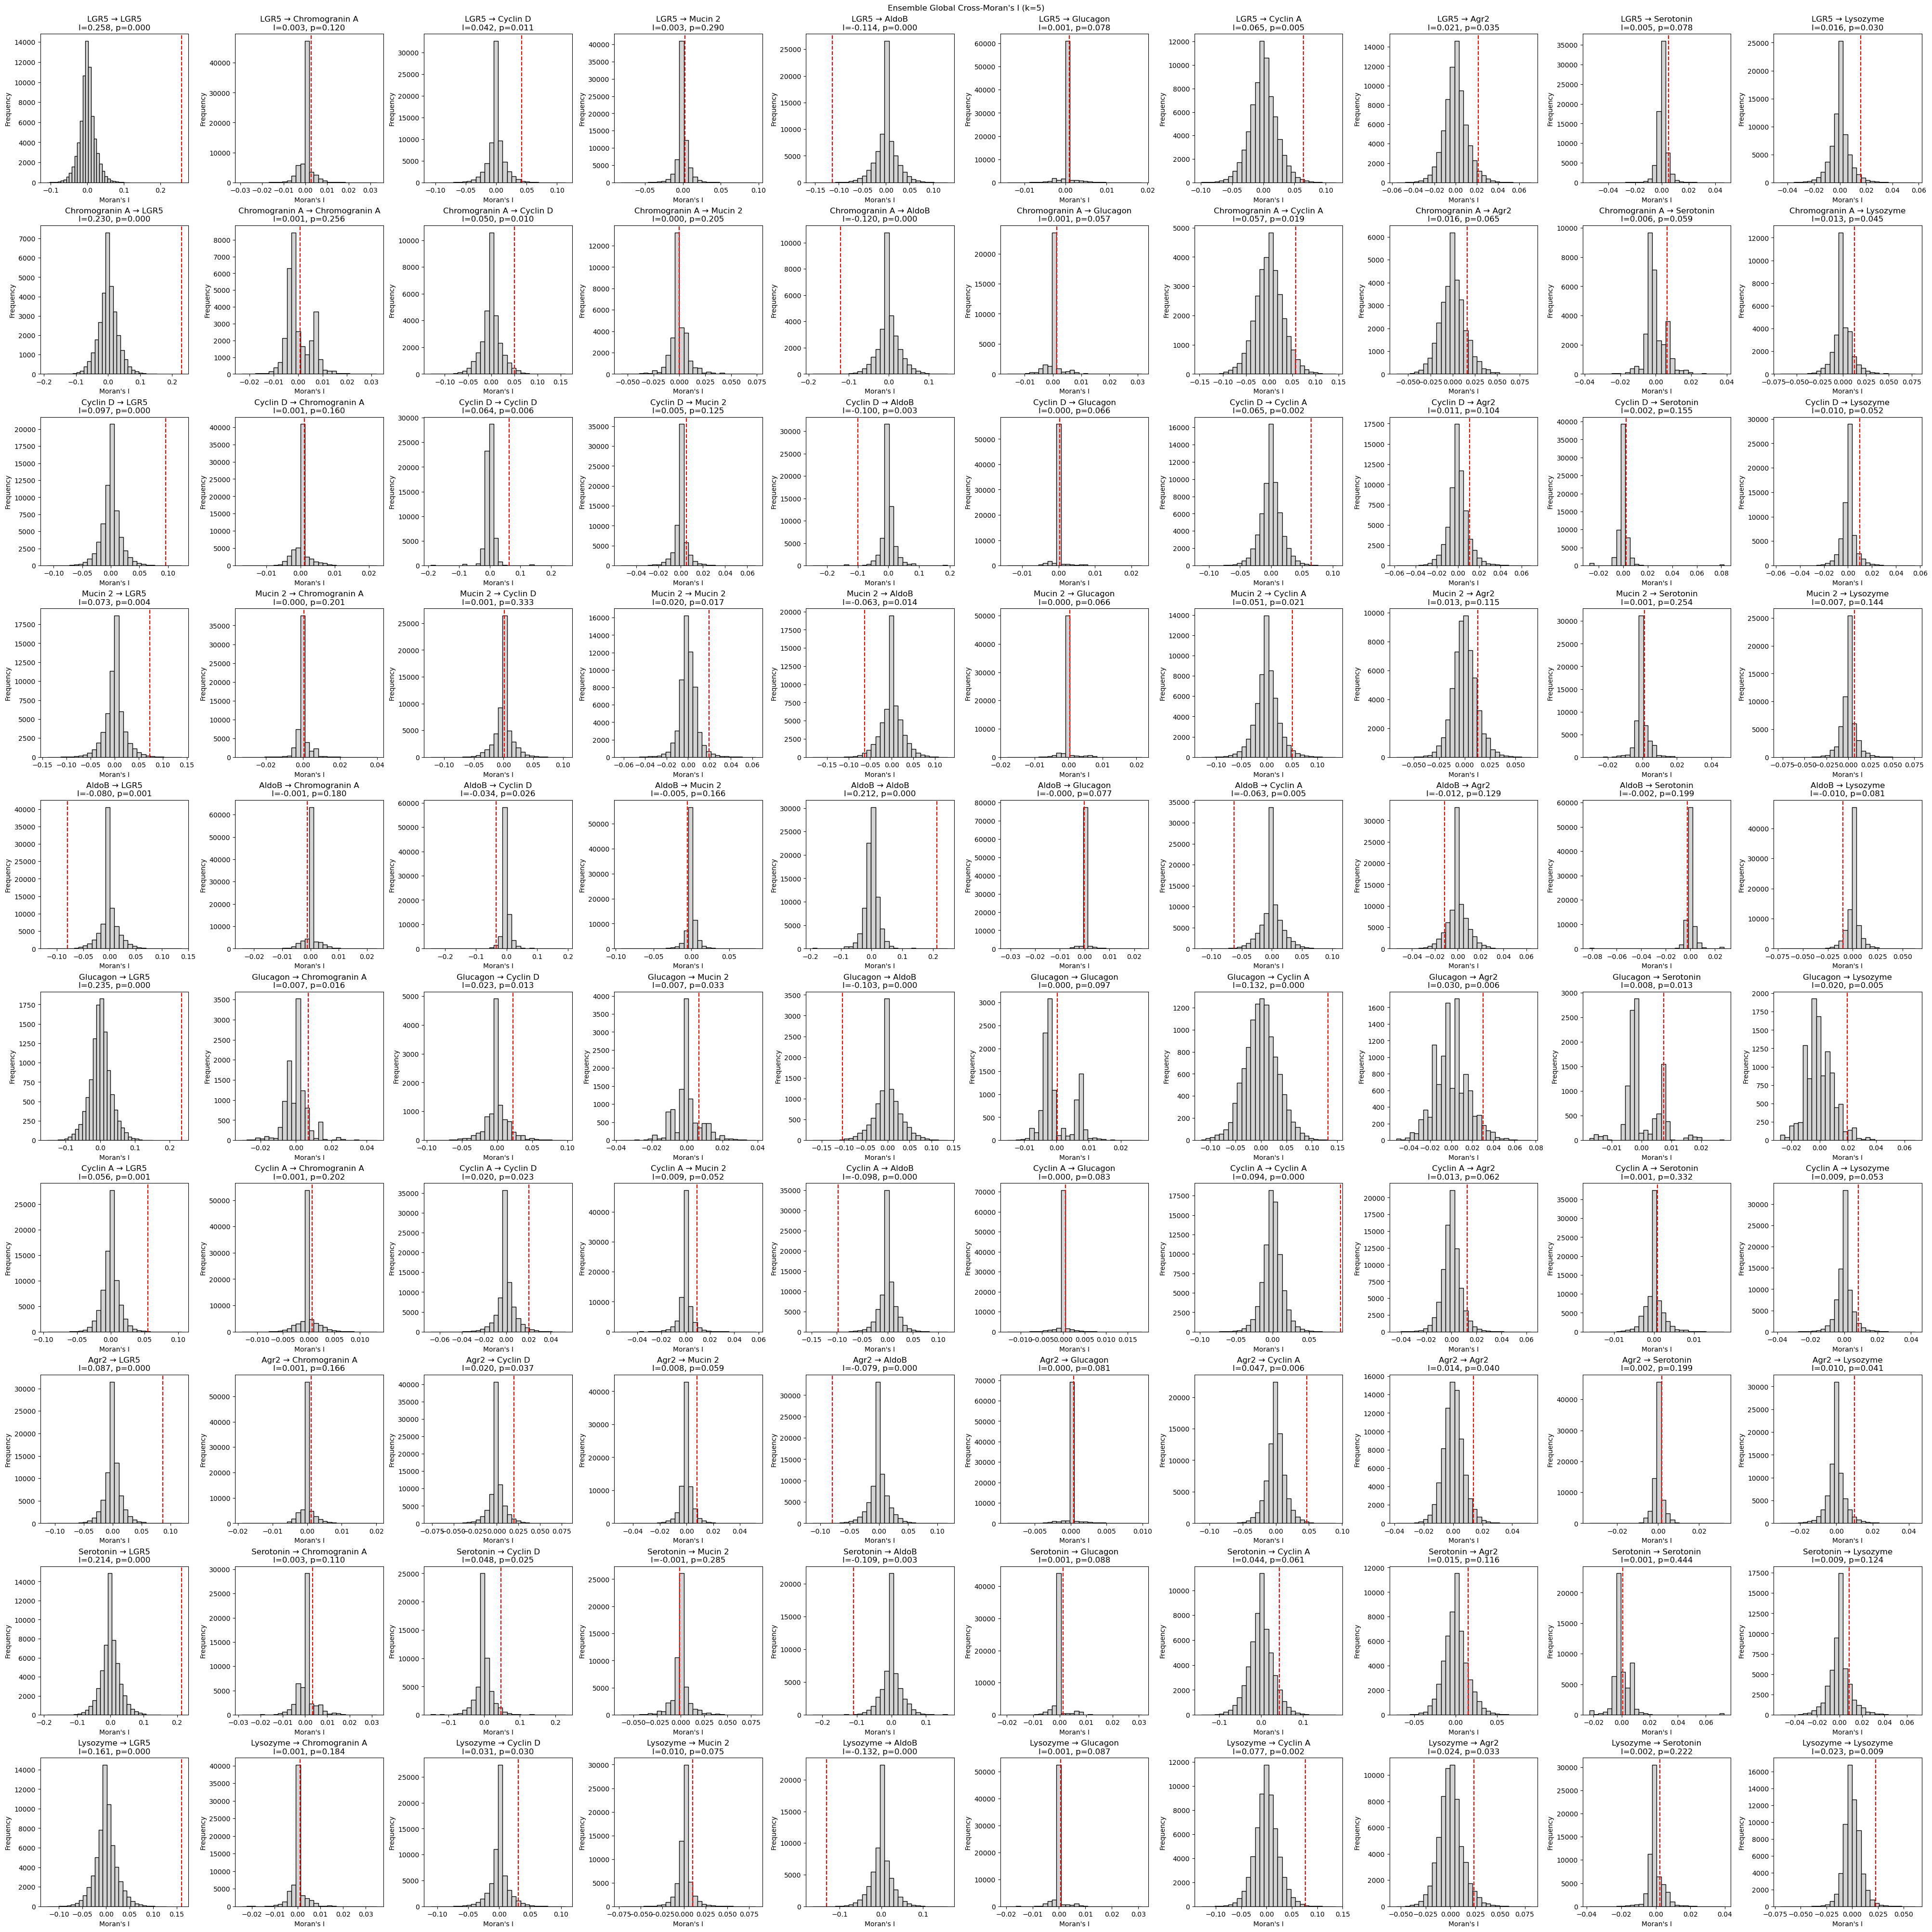

In [49]:
# --- Plot ensemble global cross-Moran's I ---
for k in k_values:
    perm_all = ensemble_global_perm[k]
    obs_mean = ensemble_global_I_mean[k]
    p_val = ensemble_p_values[k]

    fig, axes = plt.subplots(n_markers, n_markers, figsize=(4*n_markers, 4*n_markers), constrained_layout=True)
    for i in range(n_markers):
        for j in range(n_markers):
            ax = axes[i, j] if n_markers > 1 else axes
            perm_data = perm_all[:, i, j]
            perm_data = perm_data[~np.isnan(perm_data)]
            obs_value = obs_mean[i, j]
            if len(perm_data) > 0:
                ax.hist(perm_data, bins=30, color="lightgray", edgecolor="black")
                ax.axvline(obs_value, color="red", linestyle="--")
            ax.set_title(f"{marker_names[i]} → {marker_names[j]}\nI={obs_value:.3f}, p={p_val[i,j]:.3f}")
            ax.set_xlabel("Moran's I")
            ax.set_ylabel("Frequency")
    plt.suptitle(f"Ensemble Global Cross-Moran's I (k={k})")
    plt.show()
